# Regresión local

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from ISLP import load_data

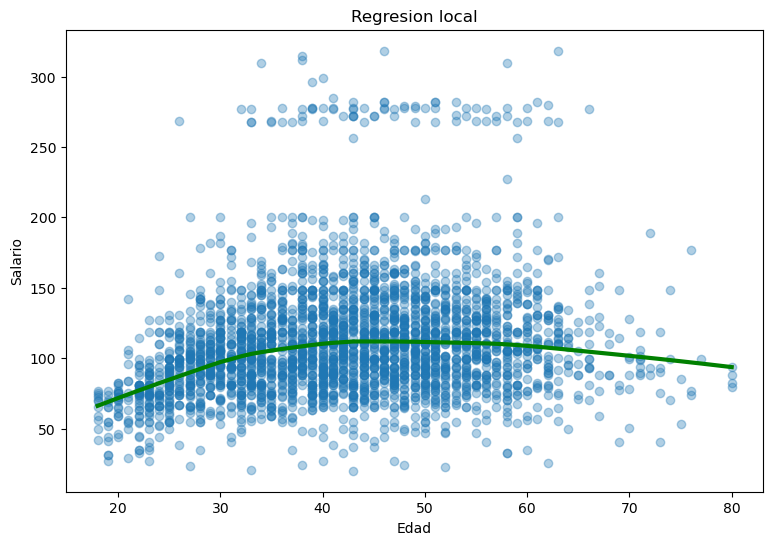

In [2]:
Wage = load_data("Wage")
age = Wage["age"]
wage = Wage["wage"]
fit_05 = lowess(wage,age, frac = 0.5)
x_lowess = fit_05[:,0]
y_lowess = fit_05[:,1]

plt.figure(figsize = (9,6))
plt.scatter(age,wage, alpha = 0.35, label = 'Datos')
plt.plot(x_lowess, y_lowess, linewidth = 3, color = 'green', label = 'Lowess: span = 0.5')

plt.xlabel('Edad')
plt.ylabel('Salario')
plt.title('Regresion local')
plt.show()

span = 0.2: aprox 600 observaciones
span = 0.5: aprox 1500 observaciones
span = 0.7: aprox 2100 observaciones


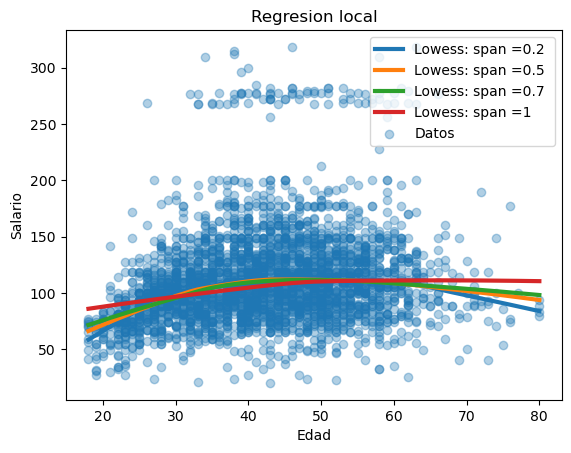

In [3]:
n = len(Wage)
for span in [0.2,0.5,0.7]:
    k = int(np.ceil(span*n))
    print(f"span = {span}: aprox {k} observaciones")

spans = [0.2,0.5, 0.7,1]
fit = {}
for span in spans:
    fit[span] = lowess(wage,age, frac = span)

plt.figure()
for span in spans:
    fitted = fit[span]

    
    plt.plot(fitted[:,0], fitted[:,1], linewidth = 3, label = f'Lowess: span ={span} ')


plt.scatter(age,wage, alpha = 0.35, label = 'Datos')
plt.xlabel('Edad')
plt.ylabel('Salario')
plt.title('Regresion local')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Observaciones alrededor de x0')

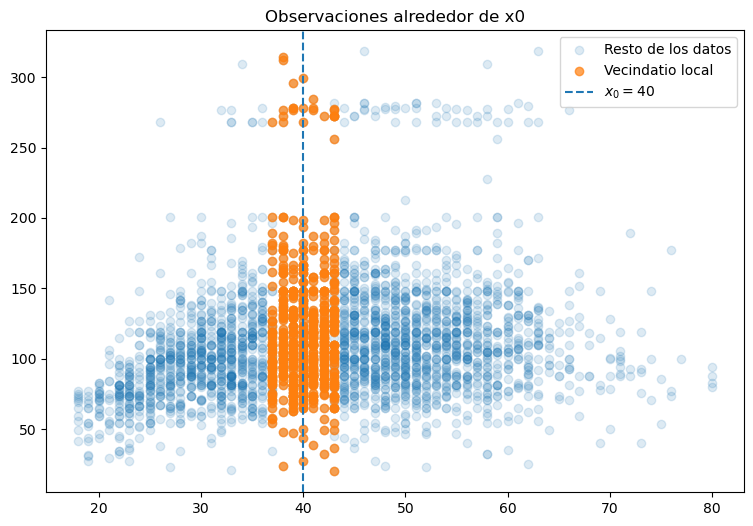

In [4]:
x0 = 40
span = 0.2
n = len(age)
k = int(np.ceil(span*n))

distance = np.abs(age.to_numpy() - x0)
nearest_idx = np.argsort(distance)[:k]
age_local = age.to_numpy()[nearest_idx]
wage_local = wage.to_numpy()[nearest_idx]
distance_local = distance[nearest_idx]

plt.figure(figsize = (9,6))
plt.scatter(age, wage, alpha = 0.15, label = "Resto de los datos")
plt.scatter(age_local, wage_local, alpha = 0.7, label = "Vecindatio local")

plt.axvline(x = x0, linestyle = "--", label = r'$x_0 = 40$')
plt.legend()
plt.title("Observaciones alrededor de x0")

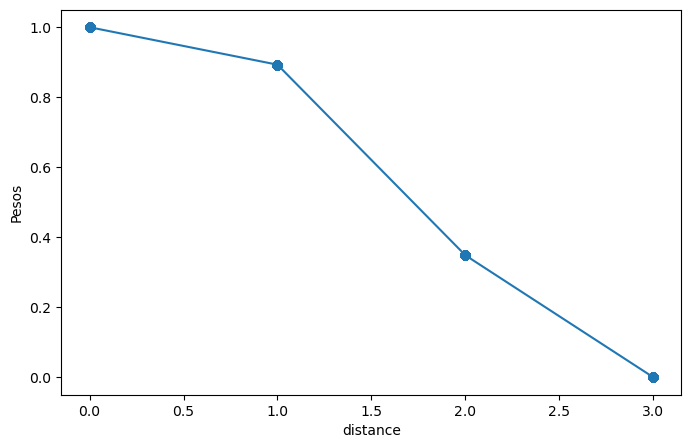

In [5]:
d_max = distance_local.max()
u = distance_local/d_max
weights = (1-u**3)**3

local_info = pd.DataFrame({'age': age_local, "wage": wage_local, 
                          "distance": distance_local, 'weight':weights})

local_info = local_info.sort_values("distance")

order = np.argsort(distance_local)

plt.figure(figsize = (8,5))
plt.plot(distance_local[order], weights[order], marker = 'o')
plt.xlabel('distance')
plt.ylabel('Pesos')
plt.show()

Text(0.5, 1.0, 'Importancia de Observaciones alrededor de x0')

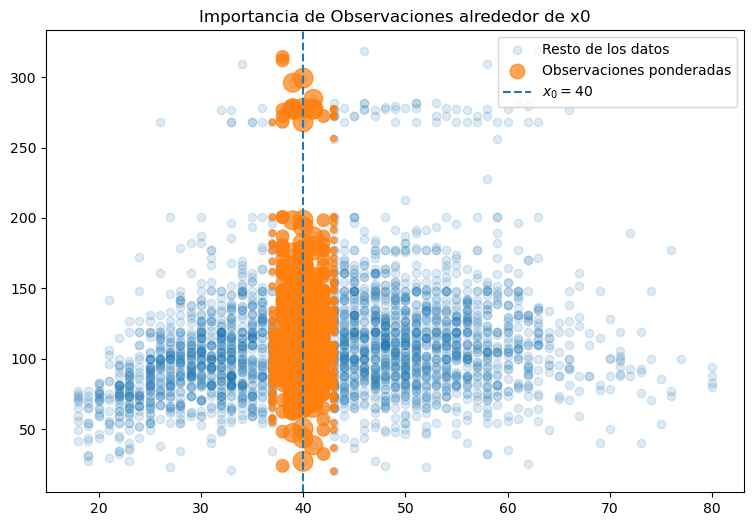

In [6]:
plt.figure(figsize = (9,6))
plt.scatter(age, wage, alpha = 0.15, label = "Resto de los datos")
plt.scatter(age_local, wage_local, s = 20+180*weights,alpha = 0.7, label = "Observaciones ponderadas")

plt.axvline(x = x0, linestyle = "--", label = r'$x_0 = 40$')
plt.legend()
plt.title("Importancia de Observaciones alrededor de x0")

In [7]:
X_local = sm.add_constant(age_local)
local_model = sm.WLS(wage_local, X_local, weights = weights).fit()
beta0, beta1 = local_model.params
prediction = beta0 + beta1*x0
prediction




np.float64(117.87698526397926)

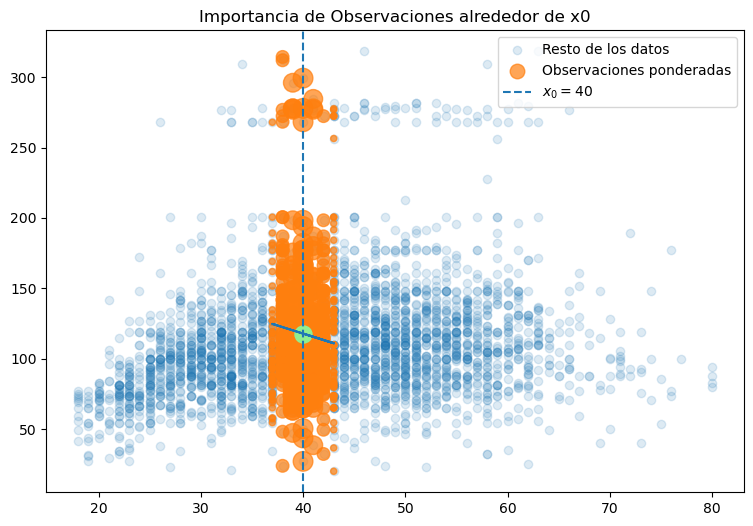

In [8]:
plt.figure(figsize = (9,6))
plt.scatter(age, wage, alpha = 0.15, label = "Resto de los datos")
plt.scatter(age_local, wage_local, s = 20+180*weights,alpha = 0.7, label = "Observaciones ponderadas")
plt.plot(age_local,beta0 + beta1*age_local)
plt.scatter([x0],[prediction],s = 150, color = 'lightgreen')
plt.axvline(x = x0, linestyle = "--", label = r'$x_0 = 40$')
plt.legend()
plt.title("Importancia de Observaciones alrededor de x0")
plt.show()

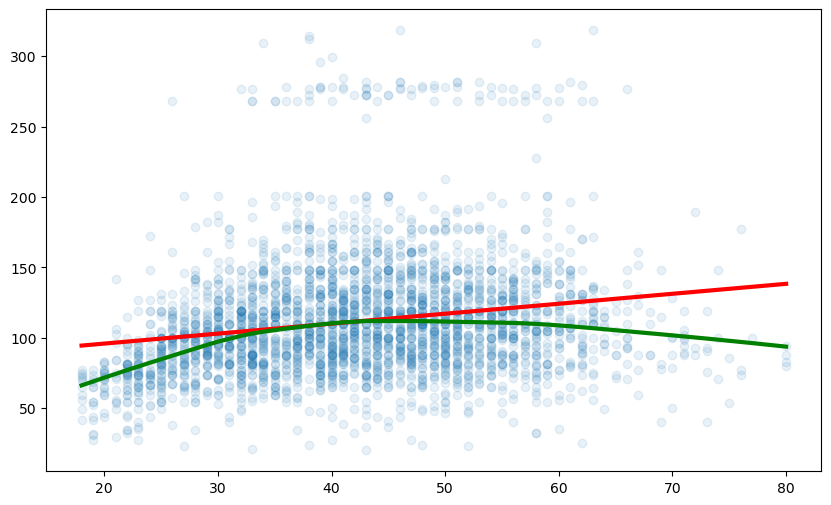

In [9]:
X_global = sm.add_constant(age)
global_model = sm.OLS(wage, X_global).fit()
age_grid = np.linspace(age.min(), age.max(), 500)
X_grid = sm.add_constant(age_grid)
global_pred= global_model.predict(X_grid)

plt.figure(figsize = (10,6))
plt.scatter(age,wage,alpha = 0.1)
plt.plot(age_grid, global_pred, linewidth = 3, color = 'red', label = "Regresión lineal Global")
plt.plot(fit_05[:,0], fit_05[:,1], linewidth = 3, color = "green", label = "regresion local")
plt.show()

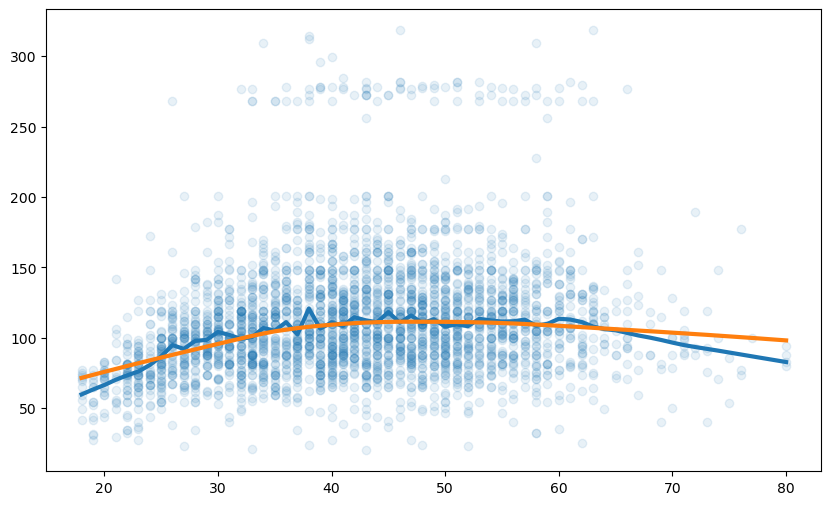

In [10]:
small_span = lowess(wage, age, frac = 0.05)
smooth_span = lowess(wage, age, frac = 0.7)


plt.figure(figsize = (10,6))
plt.scatter(age,wage,alpha = 0.1)
plt.plot(small_span[:,0], small_span[:,1], linewidth = 3, label = "Regresión lineal Global")
plt.plot(smooth_span[:,0], smooth_span[:,1], linewidth = 3, label = "Regresión lineal Global")
plt.show()

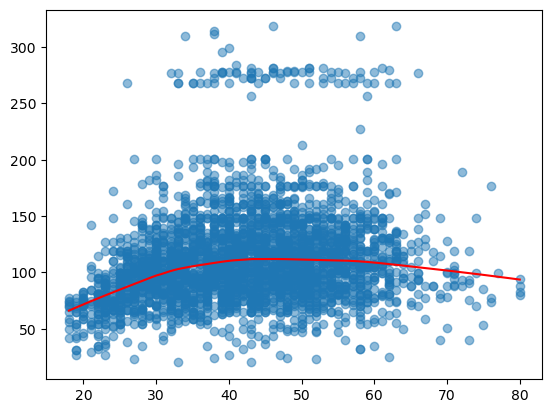

In [11]:
age_grid = np.linspace(age.min(), age.max(), 500)
age = Wage["age"]
wage = Wage["wage"]
fit_grid = lowess(wage, age, frac = 0.5, xvals = age_grid)
plt.figure()
plt.scatter(age,wage, alpha = 0.5)
plt.plot(age_grid, fit_grid, color='red')
plt.show()

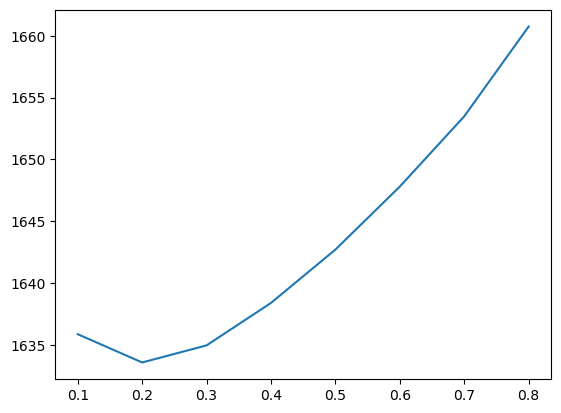

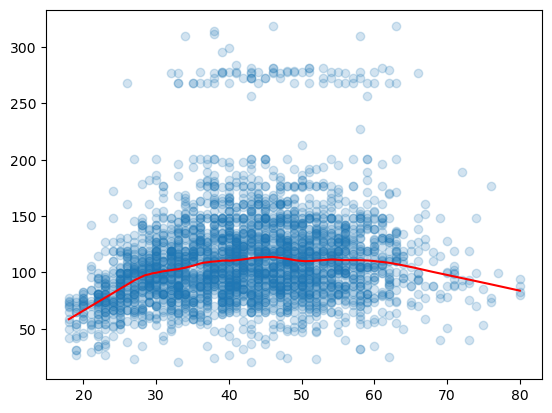

In [12]:
candidate_spans = np.arange(0.1,0.9,0.1)
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=5, shuffle = True, random_state=123)
X = age.to_numpy()
y = wage.to_numpy()

cv_results = []
for span in candidate_spans:
    fold_mse = []
    for train_idx, test_idx in kf.split(X):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_test = X[test_idx]
        y_test = y[test_idx]
        y_pred = lowess(y_train, X_train, frac = span, xvals = X_test)
        fold_mse.append(mean_squared_error(y_test,y_pred))
    cv_results.append({"span":span, 'mse': np.mean(fold_mse)})

cv_results = pd.DataFrame(cv_results)
plt.figure()
plt.plot(cv_results["span"],cv_results['mse'])
plt.show()

age_grid = np.linspace(age.min(), age.max(), 500)
age = Wage["age"]
wage = Wage["wage"]
fit_grid = lowess(wage, age, frac = 0.2, xvals = age_grid)
plt.figure()
plt.scatter(age,wage, alpha = 0.2)
plt.plot(age_grid, fit_grid, color='red')
plt.show()

# Ejercicios

## 6.28.1 Ejercicio 1. Efecto del span 
Ajusta modelos LOWESS utilizando


Representa todos los ajustes sobre la misma gráfica.

Responde:

¿Cuál produce la curva más flexible?

RESPUESTA: La de menor penalización

¿Cuál produce la curva más suave?

Respuesta: Todas parecen igual de suaves

¿En qué regiones del dominio observas mayores diferencias entre los modelos?

RESPUESTA: En los extremos

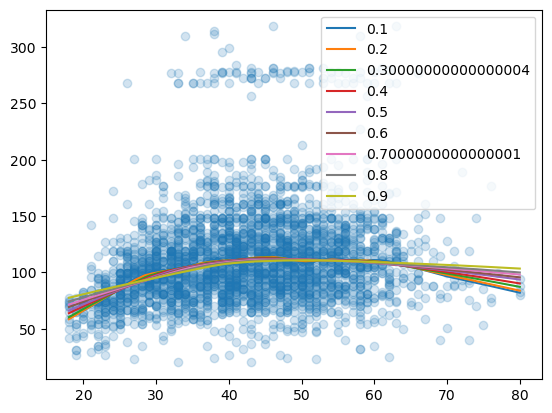

In [13]:
s = np.arange(0.1,1,0.1)
plt.figure()
plt.scatter(age,wage,alpha = 0.2)
for s1  in s:
    fit = lowess(wage,age,frac = s1, xvals=age_grid)
    plt.plot(age_grid, fit, label = f"{s1}")

plt.legend()
plt.show()

## Repite el procedimiento manual para


utilizando

x0 = 55

s = 0.2


Calcula:

el número k de observaciones utilizadas;

las distancias respecto a 
x0;

los pesos tricúbicos;

la regresión lineal ponderada;

la predicción .

Construye una gráfica que muestre el vecindario, los pesos y la recta local.

K:  600
Peso tricubico promedio:  0.5866128127999999
Regresion lineal: 97.8066353447408+ 0.36814097892952846X
prediction:  118.05438918586486
Distancia promedio: 2.45


Text(0.5, 1.0, 'Observaciones alrededor de x0')

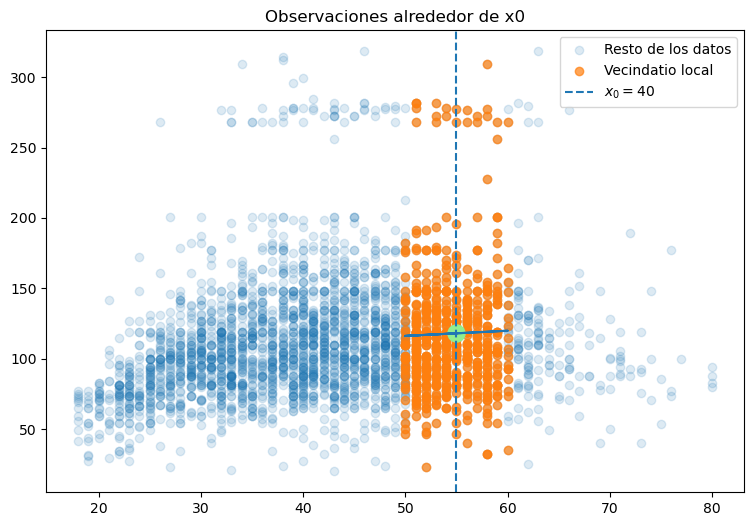

In [14]:
x0 = 55
span = 0.2
n = len(age)
k = int(np.ceil(span*n))

distance = np.abs(age.to_numpy() - x0)
nearest_idx = np.argsort(distance)[:k]
age_local = age.to_numpy()[nearest_idx]
wage_local = wage.to_numpy()[nearest_idx]
distance_local = distance[nearest_idx]


d_max = distance_local.max()
u = distance_local/d_max
weights = (1-u**3)**3

X_local = sm.add_constant(age_local)
local_model = sm.WLS(wage_local, X_local, weights = weights).fit()
beta0, beta1 = local_model.params
prediction = beta0 + beta1*x0

print("K: ", k)
print("Peso tricubico promedio: ", np.mean(weights))
print(f"Regresion lineal: {beta0}+ {beta1}X")
print("prediction: ", prediction)
print("Distancia promedio:", np.mean(distance_local))

plt.figure(figsize = (9,6))
plt.scatter(age, wage, alpha = 0.15, label = "Resto de los datos")
plt.scatter(age_local, wage_local, alpha = 0.7, label = "Vecindatio local")
plt.plot(age_local,beta0 + beta1*age_local)
plt.scatter([x0],[prediction],s = 150, color = 'lightgreen')
plt.axvline(x = x0, linestyle = "--", label = r'$x_0 = 40$')
plt.legend()
plt.title("Observaciones alrededor de x0")

## 6.28.3 Ejercicio 3. Cambiar el span localmente
Mantén


y repite el ajuste manual utilizando x= 55

0.1, 0.3, 0.6

Compara las tres predicciones.


¿Qué ocurre con el tamaño del vecindario?

Aumenta

¿Cómo cambia la recta local?

Se hace mas constante

K:  300
Peso tricubico promedio:  119.34882559836653
Regresion lineal: 167.5946854725612+ -0.8950196017481757X
prediction:  118.36860737641153
Distancia promedio: 1.1366666666666667


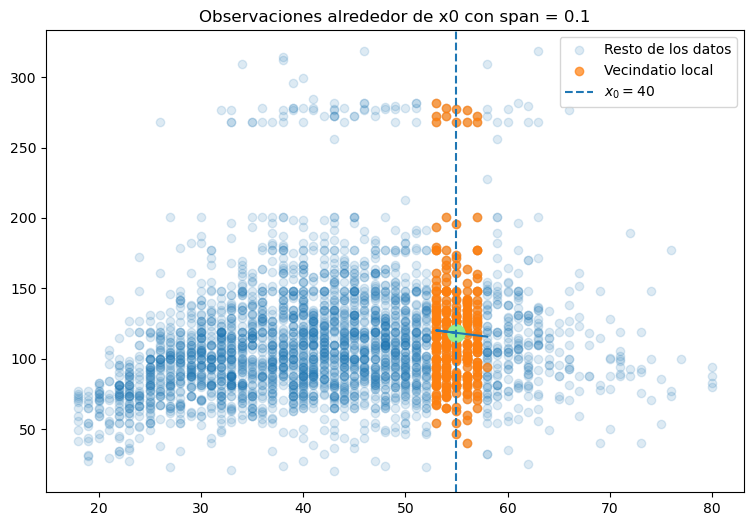

K:  900
Peso tricubico promedio:  117.46196492946981
Regresion lineal: 89.32167321022457+ 0.5223736161563343X
prediction:  118.05222209882297
Distancia promedio: 3.6644444444444444


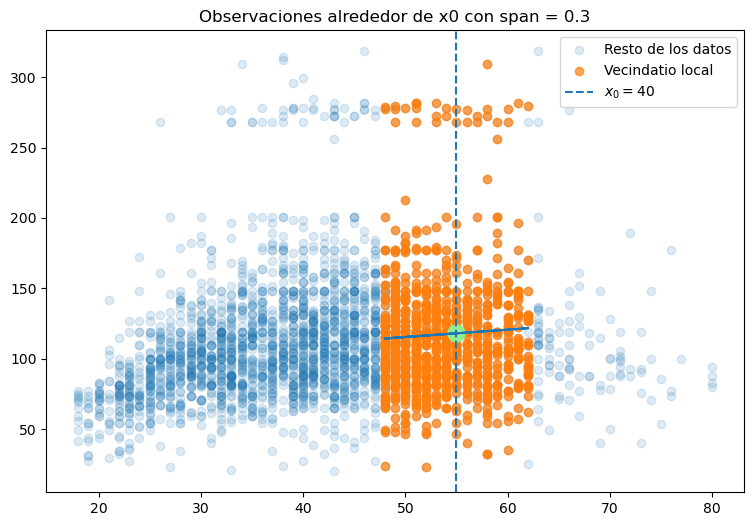

K:  1800
Peso tricubico promedio:  117.80293524762688
Regresion lineal: 117.04611741168256+ 0.02203525555330188X
prediction:  118.25805646711416
Distancia promedio: 7.639444444444444


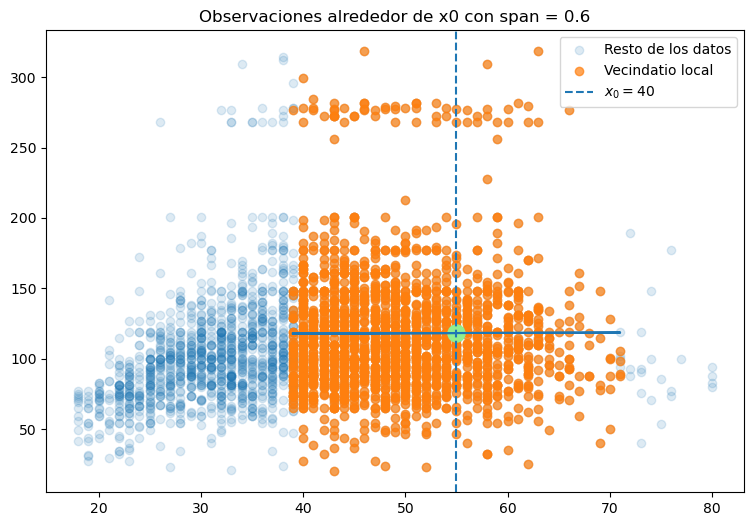

In [15]:
x0 = 55
span1 = [0.1,0.3,0.6]
for span in span1:
    n = len(age)
    k = int(np.ceil(span*n))
    
    distance = np.abs(age.to_numpy() - x0)
    nearest_idx = np.argsort(distance)[:k]
    age_local = age.to_numpy()[nearest_idx]
    wage_local = wage.to_numpy()[nearest_idx]
    distance_local = distance[nearest_idx]

    d_max = distance_local.max()
    u = distance_local/d_max
    weights = (1-u**3)**3
    
    X_local = sm.add_constant(age_local)
    local_model = sm.WLS(wage_local, X_local, weights = weights).fit()
    beta0, beta1 = local_model.params
    prediction = beta0 + beta1*x0
    
    print("K: ", k)
    print("Peso tricubico promedio: ", np.mean(wage_local))
    print(f"Regresion lineal: {beta0}+ {beta1}X")
    print("prediction: ", prediction)
    print("Distancia promedio:", np.mean(distance_local))
    
    plt.figure(figsize = (9,6))
    plt.scatter(age, wage, alpha = 0.15, label = "Resto de los datos")
    plt.scatter(age_local, wage_local, alpha = 0.7, label = "Vecindatio local")
    plt.plot(age_local,beta0 + beta1*age_local)
    plt.scatter([x0],[prediction],s = 150, color = 'lightgreen')
    plt.axvline(x = x0, linestyle = "--", label = r'$x_0 = 40$')
    plt.legend()
    plt.title(f"Observaciones alrededor de x0 con span = {span}")
    plt.show()

## 6.28.4 Ejercicio 4. Modelo global vs. local
Ajusta:

una regresión lineal global;

una regresión polinomial de grado 4;

un modelo LOWESS.

Representa los tres ajustes sobre los mismos datos.

Discute las principales diferencias entre las tres estrategias.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from ISLP import load_data
from ISLP.models import ModelSpec as MS, poly, summarize
from sklearn.linear_model import LinearRegression

#Regresion lineal
model = LinearRegression()
X = wage.to_numpy().reshape(-1,1)
X_grid = age_grid.reshape(-1,1)
model.fit(X, age)
linear_pred = model.predict(X_grid)


#Regresión local
fit = lowess(wage,age,frac = 0.2, xvals=age_grid)

#Regresion polinomial de grado 4
design_g4 = MS([poly('age', degree=4)])

X_g4 = design_g4.fit_transform(Wage)

y = Wage['wage']

modelo_g4 = sm.OLS(y, X_g4).fit()


datos_pred = pd.DataFrame({
    'age': age_grid
})



X_pred = design_g4.transform(datos_pred)

prediccion = modelo_g4.get_prediction(X_pred)

# IC al 95%
resumen_pred = prediccion.summary_frame(alpha=0.05) 




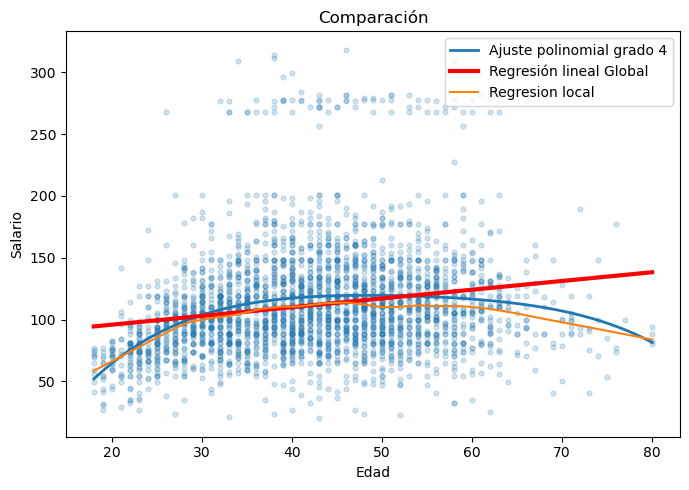

In [21]:
plt.figure(figsize=(7, 5))

plt.scatter(
    age,
    wage,
    alpha=0.2,
    s=12
)

plt.plot(
    age_grid,
    resumen_pred['mean'],
    lw=2,
    label='Ajuste polinomial grado 4'
)

plt.plot(age_grid, global_pred, linewidth = 3, color = 'red', label = "Regresión lineal Global")
plt.plot(age_grid, fit, label ="Regresion local")

plt.xlabel('Edad')
plt.ylabel('Salario')
plt.title('Comparación')

plt.legend()
plt.tight_layout()
plt.show()

## 6.28.5 Ejercicio 5. Selección del span
Utiliza validación cruzada para comparar


Determina el span que minimiza el MSE promedio de validación.

Finalmente, ajusta LOWESS utilizando ese span y representa el resultado.

    span          mse
3   0.20  1633.581162
4   0.25  1633.880956
2   0.15  1634.416699
5   0.30  1634.965435
1   0.10  1635.867703
6   0.35  1636.724044
7   0.40  1638.400080
0   0.05  1638.657532
8   0.45  1640.371814
9   0.50  1642.713358
10  0.55  1645.215430
11  0.60  1647.810688
12  0.65  1650.558781
13  0.70  1653.492066
14  0.75  1656.827970
15  0.80  1660.757365
16  0.85  1665.186647
17  0.90  1670.111758
18  0.95  1676.609044


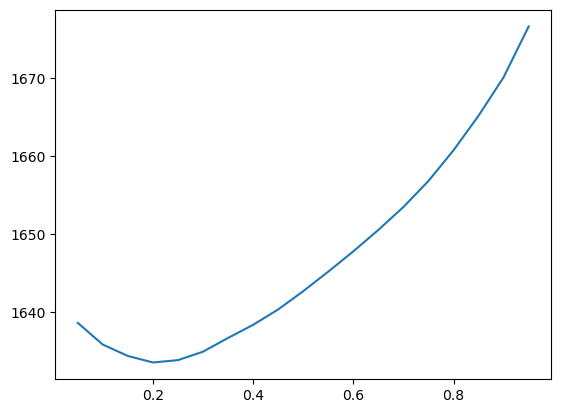

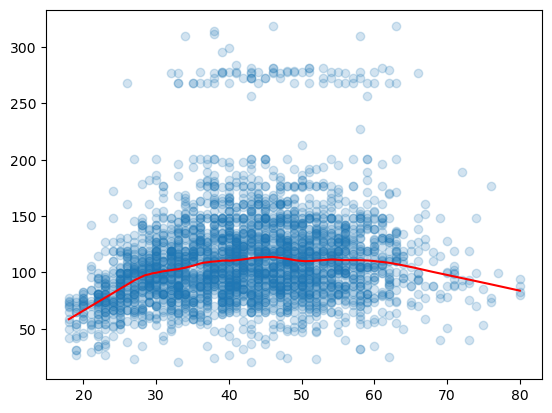

In [18]:
candidate_spans = np.arange(0.05,1,0.05)
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=5, shuffle = True, random_state=123)
X = age.to_numpy()
y = wage.to_numpy()

cv_results = []
for span in candidate_spans:
    fold_mse = []
    for train_idx, test_idx in kf.split(X):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_test = X[test_idx]
        y_test = y[test_idx]
        y_pred = lowess(y_train, X_train, frac = span, xvals = X_test)
        fold_mse.append(mean_squared_error(y_test,y_pred))
    cv_results.append({"span":span, 'mse': np.mean(fold_mse)})

cv_results = pd.DataFrame(cv_results)

print(cv_results.sort_values(by = "mse"))
plt.figure()
plt.plot(cv_results["span"],cv_results['mse'])
plt.show()

age_grid = np.linspace(age.min(), age.max(), 500)
age = Wage["age"]
wage = Wage["wage"]
fit_grid = lowess(wage, age, frac = 0.2, xvals = age_grid)
plt.figure()
plt.scatter(age,wage, alpha = 0.2)
plt.plot(age_grid, fit_grid, color='red')
plt.show()

## 6.28.6 Ejercicio 6. Interpretación
Explica con tus propias palabras por qué una colección de regresiones lineales locales puede producir una función global no lineal.

Tu explicación debe hacer referencia a:

x0;
el vecindario;
los pesos;
b0;
b1;.

RESPUESTA: porque al tomar un punto x0 toma sus vecinos mas cercanos y le asigna sus pesos dependiendo de la distancia, y en base a eso hace una regresion lineal con parametros b0 y b1 y finalmente lo hace para cada punto lo cual crea un regresion que no se parece a algo polinomial ya que a cada punto le asigna una pendiente y una regresion lineal